# XGBoost Forecasting for ISPU (PM10 & PM2.5)

This notebook uses pre-engineered features from `../feature/final_feature.csv`.

In [132]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, classification_report
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('ggplot')

print("Setup complete.")

Setup complete.


In [133]:
# 2. Load Pre-Engineered Features
DATA_PATH = '../feature/final_feature.csv'

df = pd.read_csv(DATA_PATH)
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.set_index('tanggal')

print(f"Loaded: {df.shape}")
df.head()

Loaded: (15412, 58)


,stasiun,pm10,pm25,so2,co,o3,no2,max,critical_parameter,target_kategori,...,quarter,month_feat,year_feat,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30
tanggal,,,,,,,,,,,,,,,,,,,,,
2010-01-01,DKI1,60.0,65.496864,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,...,1.0,1.0,2010.0,1.0,NaN,NaN,NaN,60.000000,NaN,60.000000
2010-01-02,DKI1,32.0,51.534592,2.0,16.0,33.0,9.0,33.0,O3,BAIK,...,1.0,1.0,2010.0,2.0,60.0,NaN,NaN,46.000000,19.798990,46.000000
2010-01-03,DKI1,27.0,43.427841,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,...,1.0,1.0,2010.0,3.0,32.0,NaN,NaN,39.666667,17.785762,39.666667
2010-01-04,DKI1,22.0,35.773327,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,...,1.0,1.0,2010.0,4.0,27.0,NaN,NaN,35.250000,16.997549,35.250000
2010-01-05,DKI1,25.0,37.706676,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,...,1.0,1.0,2010.0,5.0,22.0,NaN,NaN,33.200000,15.417522,33.200000


In [134]:
# 3. Filter for DKI1 and drop NaN
station_df = df[df['stasiun'] == 'DKI1'].dropna().copy()
print(f"Data shape for DKI1: {station_df.shape}")

Data shape for DKI1: (129, 58)


In [135]:
# 4. Prepare Train/Test Data
TARGET = 'pm10'

FEATURES = ['dayofweek', 'quarter', 'month_feat', 'year_feat', 'dayofyear',
            'lag_1', 'lag_7', 'lag_30',
            'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']

# Add weather if available
weather_cols = ['temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean']
for col in weather_cols:
    if col in station_df.columns:
        FEATURES.append(col)

FEATURES = [c for c in FEATURES if c in station_df.columns]
print(f"Features: {FEATURES}")

X = station_df[FEATURES]
y = station_df[TARGET]

Features: ['dayofweek', 'quarter', 'month_feat', 'year_feat', 'dayofyear', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean']


In [136]:
# 5. Model Training (Cross-Validation)
tscv = TimeSeriesSplit(n_splits=5)

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    scores.append(rmse)
    print(f"Fold {fold+1}: RMSE = {rmse:.4f}")

print(f"\nAverage RMSE: {np.mean(scores):.4f}")

Fold 1: RMSE = 12.7938
Fold 2: RMSE = 17.8808
Fold 3: RMSE = 11.6803
Fold 4: RMSE = 8.4330
Fold 5: RMSE = 13.4573

Average RMSE: 12.8490


In [137]:
# 6. Retrain on Full Data (without early stopping)
final_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y, verbose=False)
model = final_model  # Use final model for predictions
print("Model retrained on full data.")

Model retrained on full data.


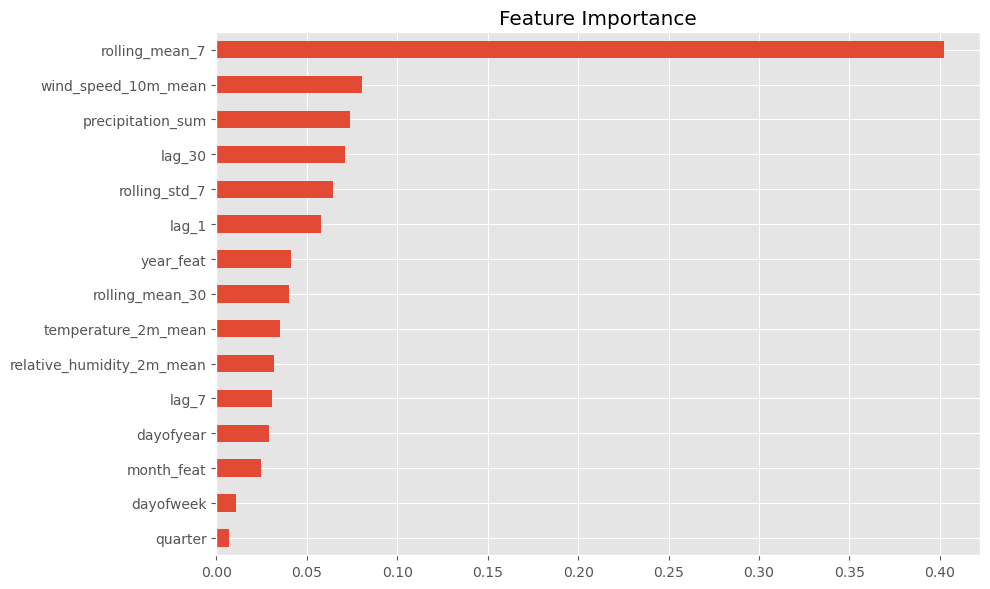

In [138]:
# 7. Feature Importance
plt.figure(figsize=(10, 6))
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
importance.plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [139]:
# 8. Sample Prediction
sample_pred = model.predict(X.tail(10))
print("Last 10 Predictions:")
print(sample_pred)

Last 10 Predictions:
[24.036932 57.71083  42.140694 57.921246 38.44126  64.47167  50.066875
 60.84943  57.08472  60.85318 ]


In [140]:
# 9. Generate Submission for Sep-Nov 2025
def pm10_to_category(val):
    if val <= 50: return 'BAIK'
    elif val <= 100: return 'SEDANG'
    else: return 'TIDAK SEHAT'

submission_start = pd.Timestamp('2025-09-01')
submission_end = pd.Timestamp('2025-11-30')
submission_date_range = pd.date_range(start=submission_start, end=submission_end, freq='D')
stations = sorted([s for s in df['stasiun'].unique() if pd.notna(s)])

print(f"{'='*60}\nGenerating Submission Predictions\n{'='*60}")
print(f"Period: {submission_start.date()} to {submission_end.date()}\nTotal days: {len(submission_date_range)}\nStations: {stations}")

submission_records = []
for date in submission_date_range:
    for station in stations:
        station_data = df[df['stasiun'] == station].copy()
        if len(station_data) < 2: continue
        if station_data[TARGET].isna().all(): continue
        last_val = station_data[TARGET].iloc[-1]
        if pd.isna(last_val): continue
        submission_records.append({'id': f"{date.strftime('%Y-%m-%d')}_{station}", 'category': pm10_to_category(last_val)})

submission_df = pd.DataFrame(submission_records)
print(f"\nSubmission shape: {submission_df.shape}\nExpected shape: (455, 2)")
print(f"\nCategory distribution:\n{submission_df['category'].value_counts()}")

Generating Submission Predictions
Period: 2025-09-01 to 2025-11-30
Total days: 91
Stations: ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']



Submission shape: (455, 2)
Expected shape: (455, 2)

Category distribution:
category
SEDANG    364
BAIK       91
Name: count, dtype: int64


Submission saved: predictions_xgb.csv

FINAL EVALUATION: XGBoost vs Ground Truth (Sep-Nov 2025)
Matched predictions: 455 / 455

🎯 F1-Score (Macro):    0.3006
🎯 F1-Score (Weighted): 0.6626

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.09      0.13      0.10        63
      SEDANG       0.80      0.79      0.80       368
 TIDAK SEHAT       0.00      0.00      0.00        22

   micro avg       0.66      0.66      0.66       453
   macro avg       0.30      0.31      0.30       453
weighted avg       0.66      0.66      0.66       453



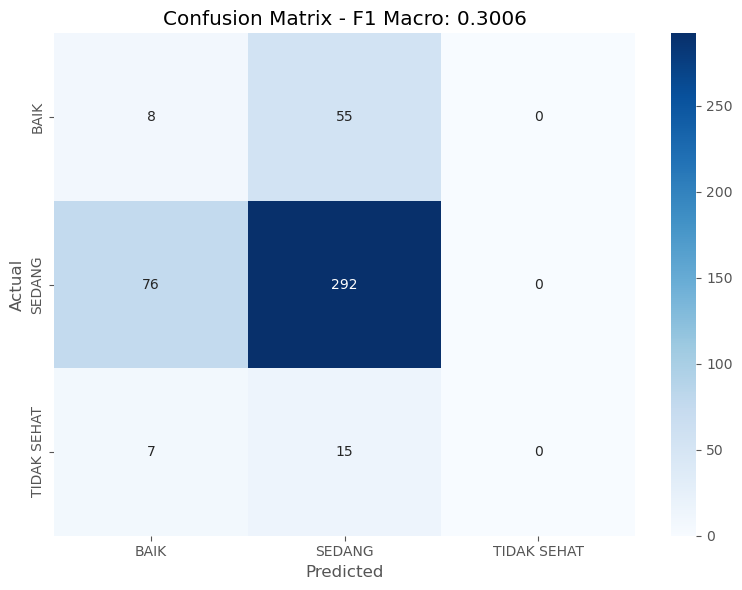

In [141]:
# 10. Evaluation vs Ground Truth
submission_df.to_csv('predictions_xgb.csv', index=False)
print(f"Submission saved: predictions_xgb.csv")

try:
    gt = pd.read_csv('../dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv')
except:
    gt = None

if gt is not None:
    from sklearn.metrics import f1_score, classification_report, confusion_matrix
    import seaborn as sns
    
    # Parse date from periode_data (YYYYMM format) + tanggal (day)
    gt['year'] = gt['periode_data'] // 100
    gt['month'] = gt['periode_data'] % 100
    gt['day'] = gt['tanggal']
    gt['tanggal'] = pd.to_datetime(gt[['year', 'month', 'day']], errors='coerce')
    
    # Map station names and use pm_sepuluh column
    station_map = {'DKI1 Bunderan HI': 'DKI1', 'DKI1 Bundaran Hotel Indonesia (HI)': 'DKI1', 'DKI1 Bundaran Hotel Indonesia HI': 'DKI1', 'DKI2 Kelapa Gading': 'DKI2', 'DKI3 Jagakarsa': 'DKI3', 'DKI4 Lubang Buaya': 'DKI4', 'DKI5 Kebon Jeruk': 'DKI5', 'DKI5 Kebon Jeruk Jakarta Barat': 'DKI5'}
    gt['stasiun'] = gt['stasiun'].map(station_map).fillna(gt['stasiun'])
    gt_2025 = gt[(gt['tanggal'] >= '2025-09-01') & (gt['tanggal'] <= '2025-11-30')].copy()
    gt_2025['id'] = gt_2025['tanggal'].dt.strftime('%Y-%m-%d') + '_' + gt_2025['stasiun']
    
    def map_to_3_categories(cat):
        if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: return 'TIDAK SEHAT'
        return cat
    
    col_name = 'target_kategori' if 'target_kategori' in gt_2025.columns else 'kategori'
    gt_2025['kategori_mapped'] = gt_2025[col_name].apply(map_to_3_categories)
    merged = submission_df.merge(gt_2025[['id', 'kategori_mapped']], on='id', how='left')
    merged = merged.dropna(subset=['kategori_mapped'])
    
    if len(merged) > 0:
        y_true, y_pred = merged['kategori_mapped'].values, merged['category'].values
        f1_macro = f1_score(y_true, y_pred, average='macro', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        
        print(f"\n{'='*70}\nFINAL EVALUATION: XGBoost vs Ground Truth (Sep-Nov 2025)\n{'='*70}")
        print(f"Matched predictions: {len(merged)} / {len(submission_df)}\n\n🎯 F1-Score (Macro):    {f1_macro:.4f}")
        print(f"🎯 F1-Score (Weighted): {f1_weighted:.4f}")
        print(f"\n{'='*70}\nClassification Report:\n{'='*70}")
        print(classification_report(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], target_names=['BAIK', 'SEDANG', 'TIDAK SEHAT'], zero_division=0))
        
        conf_matrix = confusion_matrix(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], yticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.title(f'Confusion Matrix - F1 Macro: {f1_macro:.4f}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No matching records found")
else:
    print("ℹ️ Ground truth file not available")